In [1]:
from foamdapy.tools import *
from foamdapy import EnSim2
from foamdapy.foamer import OFCase
import matplotlib.pyplot as plt
from foamdapy.ensemble_builder import ensemble_case_builder
import numpy as np
import shutil

# damBreakでサンタさんを作る

## 1.アンサンブルメンバの準備

In [2]:
%%bash
endir="./ensim_santa"
pwd_dir=`pwd`

rm -r $endir

# ディレクトリあるなら実行しない
if [ -d $endir ]; then exit; fi;
# OpenFOAMの環境変数を読み込んでいないなら実行しない
if [ ! -d $FOAM_TUTORIALS ]; then  exit; fi;

# ディレクトリ生成
mkdir -p $endir

# caseのコピー
cp -r ../of_cases/santaBreak $endir/santaBreak.org

# Allrun
# cd $endir/santaBreak.org ; ./Allrun

In [3]:
endir="./ensim_santa"
memberPrefix = "santaBreak_"
orgCase = "santaBreak.org"


In [4]:
from foamdapy.foamer import OFCase
from foamdapy.tools import decimal_normalize

endTime = 0.1 #7 
writeInterval = 0.05

#n_ensemble = 20 #4
n_ensemble = 20 #5 0.40210844

#flg_localize = False #6
flg_localize = True #7
localize_dis = 0.15 #7


In [5]:

orgcase = OFCase(f"{endir}/{orgCase}")
orgcase.exec_ofcmd("blockMesh")
orgcase.forcast(decimal_normalize(endTime))

casesbuilder = ensemble_case_builder(f"{endir}/{orgCase}",f"{endir}/member", f"{memberPrefix}")
casesbuilder.org_clones(n_ensemble)

!ls ensim_santa/member


santaBreak_00  santaBreak_04  santaBreak_08  santaBreak_12  santaBreak_16
santaBreak_01  santaBreak_05  santaBreak_09  santaBreak_13  santaBreak_17
santaBreak_02  santaBreak_06  santaBreak_10  santaBreak_14  santaBreak_18
santaBreak_03  santaBreak_07  santaBreak_11  santaBreak_15  santaBreak_19


# データ同化

In [6]:

import random
from foamdapy import EnSim2, EnSim
from foamdapy.variable import esarray
import numpy as np

random.seed(0)

n_cells = 8192
n_obs_cells = 1024
x_names = ["alpha.water", "alpha_wall"]
dim_x = n_cells+n_obs_cells
y_names = ["alpha_wall"]
n_y_scaler = 1 #ベクトル問題解決までは = n_xscaler


## y0定義(目的関数の定義)

In [7]:
import pandas as pd
import numpy as np
df = pd.read_excel(f"{endir}/{orgCase}/santa.xlsx","santa32",header=None)
y0 = np.rot90(np.rot90(df)).T.flatten()

In [8]:
from foamdapy.foamer import OFCase
import numpy as np

orgcase = OFCase(f"{endir}/{orgCase}")
xf0 = orgcase.getValues("0",["alpha.water"])

cent = orgcase.getValues("0",["Cz"])
right_wall_cell_index = np.where(cent == cent.max())[0]

var_cell_index = np.arange(0, n_cells)
var_cell_index = np.concatenate((right_wall_cell_index, var_cell_index))

cell_d = cell_distance(orgcase.case_dir)


In [9]:
def Hx(xf, column_slice):
    if xf.ndim == 1: 
        return xf[column_slice]
    return xf[:, column_slice]


ensim = EnSim2(f"{endir}/member/", memberPrefix, x_names, 
               dim_x, n_ensemble, right_wall_cell_index,
               f"{endir}/{orgCase}",4,localize=flg_localize, localize_distance=localize_dis)
ensim.y0 = y0

ensim.func_Hx = Hx
ensim.R_diag = np.ones(ensim.y0.size)*0.001

ensim.mat_d = var_obs_distance(var_cell_index, right_wall_cell_index, cell_d)
ensim.mat_d

localize is True.


array([[0.        , 0.01825   , 0.0365    , ..., 0.77471196, 0.78729239,
        0.80009132],
       [0.01825   , 0.        , 0.01825   , ..., 0.76236085, 0.77471196,
        0.78729239],
       [0.0365    , 0.01825   , 0.        , ..., 0.75025037, 0.76236085,
        0.77471196],
       ...,
       [0.77471196, 0.76236085, 0.75025037, ..., 0.        , 0.01825   ,
        0.0365    ],
       [0.78729239, 0.77471196, 0.76236085, ..., 0.01825   , 0.        ,
        0.01825   ],
       [0.80009132, 0.78729239, 0.77471196, ..., 0.0365    , 0.01825   ,
        0.        ]])

## 変数の初期化

In [12]:
from foamdapy.variable import esarray, ColumnInfo
import numpy as np

#init param
#ofset_init=0 #1 0.4548417
#ofset_init=0.5 #2 0.4707086
#ofset_init=0.5 #3 0.4589805 
ofset_init=0.3 #4 0.4104807 
#p_init = 1 #1 
#p_init = 0.2 #2
#p_init = 0.2 #3
p_init = 0.3 #4

#update param
#inf_beta = 0.8 #4
inf_beta = 0.9 #5
#ave_beta = 1 #1
# ave_beta = 0.5 #2
#ave_beta = 1 #3
ave_beta = 1 #4

deltime = np.arange(writeInterval, endTime + writeInterval, writeInterval)
del_names = [decimal_normalize(t) for t in deltime] + ["PyFoam*"]

np.random.seed(0)
ensim.xf = esarray(np.ones((n_ensemble,dim_x))) * ofset_init
#ensim.xf = esarray(p_init * np.random.random(n_ensemble*dim_x).reshape(ensim.xf.shape)- 0.5*p_init +ofset_init)
ensim.xf.add_column_info("init_alpha","alpha.water","0",(0, n_cells))
ensim.xf.add_column_info("alpha_wall","alpha.water",decimal_normalize(endTime),(n_cells, dim_x),right_wall_cell_index)

#ensim.xf.all_load("init_alpha",ensim.case_dirs(),1)
#ensim.xf.all_load("alpha_wall",ensim.case_dirs(),1)
#ensim.xf = np.clip(ensim.xf, 0,1)

ensim.xf.column_info["alpha_wall"].str_dump()



'{"name": "alpha.water", "time_name": "0.1", "indices": "slice(8192, 9216, None)", "cells": [7168, 7169, 7170, 7171, 7172, 7173, 7174, 7175, 7176, 7177, 7178, 7179, 7180, 7181, 7182, 7183, 7184, 7185, 7186, 7187, 7188, 7189, 7190, 7191, 7192, 7193, 7194, 7195, 7196, 7197, 7198, 7199, 7200, 7201, 7202, 7203, 7204, 7205, 7206, 7207, 7208, 7209, 7210, 7211, 7212, 7213, 7214, 7215, 7216, 7217, 7218, 7219, 7220, 7221, 7222, 7223, 7224, 7225, 7226, 7227, 7228, 7229, 7230, 7231, 7232, 7233, 7234, 7235, 7236, 7237, 7238, 7239, 7240, 7241, 7242, 7243, 7244, 7245, 7246, 7247, 7248, 7249, 7250, 7251, 7252, 7253, 7254, 7255, 7256, 7257, 7258, 7259, 7260, 7261, 7262, 7263, 7264, 7265, 7266, 7267, 7268, 7269, 7270, 7271, 7272, 7273, 7274, 7275, 7276, 7277, 7278, 7279, 7280, 7281, 7282, 7283, 7284, 7285, 7286, 7287, 7288, 7289, 7290, 7291, 7292, 7293, 7294, 7295, 7296, 7297, 7298, 7299, 7300, 7301, 7302, 7303, 7304, 7305, 7306, 7307, 7308, 7309, 7310, 7311, 7312, 7313, 7314, 7315, 7316, 7317, 7318, 7

In [14]:
ensim.xf.column_info["init_alpha"].str_dump()

'{"name": "alpha.water", "time_name": "0", "indices": "slice(0, 8192, None)", "cells": null}'

# DA loop

In [15]:
np.random.seed(0)

ensim.clear_log_dir()
ensim.craete_log_dir()

ensim.num_cpus = 10
sg = p_init**2

ensim.start_ray()

xf_mean =  ensim.xf.mean(axis=0) 
for i in range(50):
    
    pf =  np.random.normal(0, sg, n_ensemble*dim_x).reshape(ensim.xf.shape)
    ensim.xf = esarray(np.clip(xf_mean + pf, 0 ,1))

    # xfをOpenFOAMに反映、予報計算
    ensim.xf.all_save("init_alpha",ensim.case_dirs(),1)
    
    for dname in del_names:
        ensim.clearPatternInCases(f"{dname}")

    ensim.ensemble_forcast(decimal_normalize(endTime))

    #xfのアップデート
    ensim.xf.all_load("init_alpha",ensim.case_dirs(),1)
    ensim.xf.all_load("alpha_wall",ensim.case_dirs(),1)

    # 残差をファイルに追記
    rmse = np.sqrt((np.square(ensim.y0- ensim.xf[:,-n_obs_cells:])).mean())
    rmsefile=f'{ensim.logdir}/rmse.txt'
    mode = 'a' if os.path.exists(f'{rmsefile}') else 'w'
    with open(f'{rmsefile}', "ab") as f:
        np.savetxt(f, [rmse], fmt='%.7f')
    print(f"Iteration {i}: Residual {rmse:.7f} saved.")

    if i == 7:
        break


    ensim.letkf_update()
    ensim.xa = esarray(ensim.xa, ensim.xf.column_info)

    #inflation
    #RTPS
    xf_mean =  ensim.xa.mean(axis=0) 
    #dxa = ensim.xa - xa_mean
    #sigma_xa = ensim.xa.std(axis=0)
    #sigma_xf = ensim.xf.std(axis=0)
     
    #beta = inf_beta
    #with np.errstate(all='ignore'):
    #    rmd =(beta*sigma_xf +(1-beta)*sigma_xa)/sigma_xa
    #rmd_max = np.nan_to_num(rmd).max()
    #rmd = np.nan_to_num(rmd, nan=rmd_max)
    #rmd = np.clip(rmd, 1.0, 10.0)

    #ensim.xa = xa_mean + rmd * dxa
    ensim.save_logs(f"{i}".zfill(2))

ensim.shutdown_ray()
    

2025-02-02 12:27:15,667	INFO worker.py:1821 -- Started a local Ray instance.


Iteration 0: Residual 0.4507517 saved.
Iteration 1: Residual 0.3737438 saved.
Iteration 2: Residual 0.3160387 saved.
Iteration 3: Residual 0.2695938 saved.
Iteration 4: Residual 0.2371572 saved.
Iteration 5: Residual 0.2135112 saved.
Iteration 6: Residual 0.1927488 saved.
Iteration 7: Residual 0.1786689 saved.


In [16]:
np.sqrt((np.square(ensim.y0- ensim.xf[:,-n_obs_cells:])).mean(axis=1))

esarray([0.17984833, 0.17696696, 0.18218174, 0.17729704, 0.17933294,
         0.17967618, 0.1784061 , 0.17529665, 0.17706739, 0.17618475,
         0.18255694, 0.17791721, 0.17742214, 0.1805505 , 0.17486417,
         0.17882818, 0.1798911 , 0.17797755, 0.18135573, 0.17951771])

In [18]:
ensim.case_dirs()[13]

'./ensim_santa/member/santaBreak_09'

In [15]:
xf49 = np.load("./ensim1/member/logs/xf_iter_49.npy")

FileNotFoundError: [Errno 2] No such file or directory: './ensim1/member/logs/xf_iter_49.npy'

In [12]:
rmse = np.sqrt(np.mean(np.square(xf49[:,-50:] - ensim.y0),axis=1))
rmse.argmin(),rmse.min(),ensim.case_dirs()[rmse.argmin()]

(15, 0.36898707968153655, './ensim1/member/damBreakde1_04')

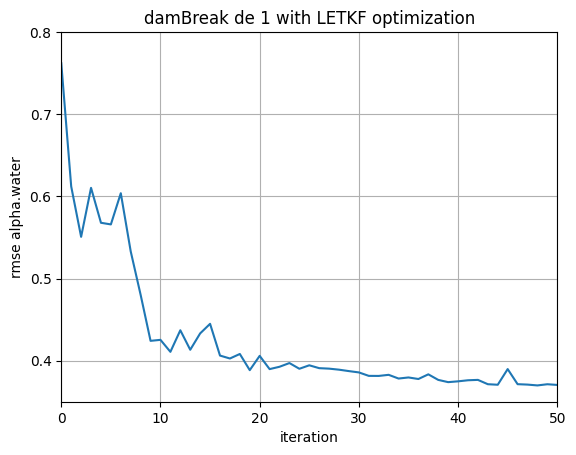

In [18]:
import matplotlib.pyplot as plt 
rmses = np.loadtxt("./ensim1/member/logs/rmse.txt")

plt.plot(rmses)
plt.grid(True)
plt.ylabel("rmse alpha.water")
plt.xlabel("iteration")
plt.xlim((0,50))
plt.ylim((0.35,0.8))
plt.title("damBreak de 1 with LETKF optimization")
plt.savefig("./ensim1/rmse.png")
plt.savefig("./ensim1/rmse.svg")

In [29]:
ensim.shutdown_ray()

In [22]:
ensim.letkf_update()

ensim.xf = np.clip(ensim.xa,0,1)
print(np.sqrt(np.mean(np.square(ensim.y0- ensim.xf[:,-50:].mean(axis=0)))))


(pid=203433)  0:   0%|          | 0/2318 [00:00<?, ?it/s]

0.4252204786504662


In [27]:
ensim.letkf_update()

ensim.xf = np.clip(ensim.xa,0,1)
print(np.sqrt(np.mean(np.square(ensim.y0- ensim.xf[:,-50:].mean(axis=0)))))


(pid=204379)  0:   0%|          | 0/2318 [00:00<?, ?it/s]

0.3361718370730322


In [29]:

ensim.xa[:,obs_cells].mean(axis=0)

array([0.        , 0.        , 0.        , 0.16707379, 0.23206047,
       0.        , 0.        , 0.        , 0.04116507, 0.22924742,
       0.80286058, 0.61897858, 0.33681699, 0.63541729, 0.99869948,
       1.        , 1.        , 1.        , 0.97612033, 0.98904975,
       0.8407334 , 1.00535363, 0.78365646, 1.        , 1.        ,
       0.86620722, 1.        , 1.        , 0.55790745, 0.97769141,
       0.88480037, 0.98495428, 0.91719447, 1.        , 0.90891519,
       0.80799352, 0.95719327, 0.        , 0.24689648, 0.24311403,
       0.46347879, 0.63059655, 0.49133201, 0.33423423, 0.23289322,
       0.        , 0.        , 0.        , 0.        , 0.08587819])

In [67]:

ensim.xf = np.clip(ensim.xa,0,1)
print(np.sqrt(np.mean(np.square(y0- ensim.xf[:,-50:].mean(axis=0)))))
ensim.letkf_update()

print(ensim.xa[:,obs_cells][:,23:27].mean(axis=0) )
ensim.xa[:,obs_cells].mean(axis=0) > 0.5

0.47113455804363336


(pid=196880)  0:   0%|          | 0/2318 [00:00<?, ?it/s]

[0.79416195 0.84179221 0.42356902 0.09836496]


array([False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False])

In [68]:
ensim.shutdown_ray()

In [39]:
ensim.xa[:,obs_cells].mean(axis=0) > 0.5

array([False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True,  True, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.])

0.848528137423857

In [29]:
np.square(y0-ensim.xa.mean(axis=0)[-50])

array([2.79747196e-05, 2.79747196e-05, 2.79747196e-05, 2.79747196e-05,
       2.79747196e-05, 2.79747196e-05, 2.79747196e-05, 2.79747196e-05,
       2.79747196e-05, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 1.01060620e+00, 1.01060620e+00, 1.01060620e+00,
       1.01060620e+00, 2.79747196e-05, 2.79747196e-05, 2.79747196e-05,
       2.79747196e-05, 2.79747196e-05])

array([False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False])

In [54]:
fromXset = {"alpha.water":(slice(0,n_cells),"0",["alpha.water"],None),
            "alpha_wall":(slice(n_cells, dim_x),"0.45",["alpha.water"],obs_cells)}

In [19]:
fromXset = {"alpha.water":(slice(0,n_cells),"0",["alpha.water"],None),
            "alpha_wall":(slice(n_cells, dim_x),"0.45",["alpha.water"],obs_cells)}

def func_get_xfi(case, fromXset):
    xf = esarray(np.empty(dim_x))
    for key in fromXset:
        xslice = fromXset[key][0]
        time_name = fromXset[key][1]
        x_name = fromXset[key][2]
        cells = fromXset[key][3]
        xf[xslice] = case.getValues(time_name, x_name, cells)
    return xf

ensim.func_get_xfi = func_get_xfi
xfn = ensim.get_xf(ensim.cases, fromXset)
sd = {k: v[0] for k,v in fromXset.items()}
xf = esarray(xfn.T,state_dict=sd)


In [17]:
ensim.func_get_xfi = func_get_xfi
xfn = ensim.get_xf(ensim.cases, fromXset)
sd = {k: v[0] for k,v in fromXset.items()}
xf = esarray(xfn.T,state_dict=sd)

In [18]:
xf.get_st_value("alpha.water").shape

(20, 2268)

In [6]:
fromXset = {"alpha.water":("0.45","alpha.water",None),
            "alpha_wall":("0.45","alpha.water",obs_cells)}

<function dict.keys>

In [54]:
ensim.x_names = ["alpha.water"]
ensim.n_x_scaler=1


In [19]:
#ensim.xf=aaa
#cp -r member/case/0.org member/case/0
#member/case/0/alpha.water  ← ensim.xf
#ensim.forcast()
#ensim.xf[:,-500:] =get wall values form 0.45/alpha.water


In [4]:
from foamdapy.foamer import OFCase
orgcase = OFCase("./ensim1/damBreak.org")
xf0 = orgcase.getValues("0",["alpha.water"])

cent = orgcase.getValues("0",["Cx"])
right_wall_index = np.where(cent == cent.max())[0]
xf1 = orgcase.getValues("0.45", ["alpha.water"],right_wall_index)

In [37]:
xf1

array([3.05857e-08, 7.12736e-08, 8.55904e-07, 8.82821e-06, 6.12643e-05,
       3.15497e-04, 1.27076e-03, 4.16149e-03, 1.11767e-02, 3.93311e-02,
       4.84632e-01, 8.21182e-01, 8.73722e-01, 9.15934e-01, 9.39197e-01,
       9.39197e-01, 9.39197e-01, 9.04085e-01, 8.84089e-01, 7.43213e-01,
       7.41936e-01, 7.42119e-01, 8.07415e-01, 8.79520e-01, 8.71844e-01,
       3.87061e-01, 6.89088e-02, 6.64392e-02, 6.62257e-02, 6.62133e-02,
       6.62147e-02, 9.33018e-02, 2.79253e-01, 2.78850e-01, 2.77716e-01,
       2.77142e-01, 2.76247e-01, 2.73630e-01, 2.70896e-01, 2.67770e-01,
       2.66089e-01, 2.59374e-01, 2.39460e-01, 2.35279e-01, 2.32942e-01,
       1.93779e-01, 7.48833e-02, 9.84003e-02, 1.15263e-01, 8.34962e-02])

In [3]:
from PyFoam.RunDictionary.ParsedParameterFile import ParsedParameterFile


In [4]:
al = ParsedParameterFile("./ensim1/damBreak.org/0.45/alpha.water")

In [15]:
al.content["boundaryField"]

{'leftWall': {'type': 'zeroGradient'},
 'rightWall': {'type': 'zeroGradient'},
 'lowerWall': {'type': 'zeroGradient'},
 'atmosphere': {'type': 'inletOutlet',
  'inletValue': 'uniform 0',
  'value': 'nonuniform List<scalar> 46
  (
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0
    0.00558338
    0
    0
    6.78416e-05
    6.78416e-05
    0.0834962
  )
  '},
 'defaultFaces': {'type': 'empty'}}